# Testing Out New Classes

In [1]:
from utils_3 import PairwiseData

In [2]:
from datasets import load_dataset

ds = load_dataset("lmarena-ai/arena-human-preference-140k", )
ds = dict(ds)

/soda/jnzhao3/micromamba/envs/ld/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ds

{'train': Dataset({
     features: ['id', 'model_a', 'model_b', 'winner', 'evaluation_session_id', 'evaluation_order', 'conversation_a', 'conversation_b', 'full_conversation', 'conv_metadata', 'category_tag', 'language', 'is_code', 'timestamp'],
     num_rows: 135634
 })}

In [4]:
pw = PairwiseData(ds, M=30, N=30)

In [5]:
pw.winners

array([ 1, 26, 29, ..., 23, 21, 13], shape=(37454,))

In [6]:
import numpy as np
subgroups, count = np.unique(pw.subgroups, return_counts=True)

In [7]:
subgroups

array([   0,   64,   68,   76,   80,   92,   96,  100,  112,  124,  192,
        224,  240,  248,  252,  364,  366,  380,  382,  432,  508,  509,
        512, 1024, 1148, 1276, 1388, 1404, 1532, 1533], dtype=uint32)

In [8]:
count

array([4091, 1620, 1588, 1249,  412,  616,  466,  760,  427,  515,  812,
        980, 1257, 1505, 1290,  712,  727, 1070,  489,  488, 2251, 2032,
        425,  480,  593, 1222,  424, 1949, 3995, 3009])

In [9]:
len(subgroups)

30

In [10]:
pw.candidates_to_idx

{np.str_('claude-opus-4-20250514'): 0,
 np.str_('gemini-2.5-pro'): 1,
 np.str_('gemini-2.5-flash'): 2,
 np.str_('qwen3-235b-a22b-no-thinking'): 3,
 np.str_('mistral-medium-2505'): 4,
 np.str_('o3-2025-04-16'): 5,
 np.str_('claude-sonnet-4-20250514'): 6,
 np.str_('chatgpt-4o-latest-20250326'): 7,
 np.str_('claude-3-7-sonnet-20250219-thinking-32k'): 8,
 np.str_('gemma-3-27b-it'): 9,
 np.str_('claude-3-7-sonnet-20250219'): 10,
 np.str_('claude-3-5-sonnet-20241022'): 11,
 np.str_('o3-mini'): 12,
 np.str_('command-a-03-2025'): 13,
 np.str_('deepseek-r1-0528'): 14,
 np.str_('claude-3-5-haiku-20241022'): 15,
 np.str_('gpt-4.1-2025-04-14'): 16,
 np.str_('o4-mini-2025-04-16'): 17,
 np.str_('claude-opus-4-20250514-thinking-16k'): 18,
 np.str_('amazon.nova-pro-v1:0'): 19,
 np.str_('grok-3-preview-02-24'): 20,
 np.str_('deepseek-v3-0324'): 21,
 np.str_('gpt-4.1-mini-2025-04-14'): 22,
 np.str_('llama-4-maverick-03-26-experimental'): 23,
 np.str_('gemini-2.0-flash-001'): 24,
 np.str_('grok-3-mini-be

In [11]:
set(pw.subgroups)

{np.uint32(0),
 np.uint32(64),
 np.uint32(68),
 np.uint32(76),
 np.uint32(80),
 np.uint32(92),
 np.uint32(96),
 np.uint32(100),
 np.uint32(112),
 np.uint32(124),
 np.uint32(192),
 np.uint32(224),
 np.uint32(240),
 np.uint32(248),
 np.uint32(252),
 np.uint32(364),
 np.uint32(366),
 np.uint32(380),
 np.uint32(382),
 np.uint32(432),
 np.uint32(508),
 np.uint32(509),
 np.uint32(512),
 np.uint32(1024),
 np.uint32(1148),
 np.uint32(1276),
 np.uint32(1388),
 np.uint32(1404),
 np.uint32(1532),
 np.uint32(1533)}

In [12]:
pw.data_by_subgroups([204])

{'winners': array([], dtype=int64),
 'losers': array([], dtype=int64),
 'subgroups': array([], dtype=uint32)}

In [13]:
import numpy as np

s, c = np.unique(pw.subgroups, return_counts=True)

In [14]:
np.sort(-c)

array([-4091, -3995, -3009, -2251, -2032, -1949, -1620, -1588, -1505,
       -1290, -1257, -1249, -1222, -1070,  -980,  -812,  -760,  -727,
        -712,  -616,  -593,  -515,  -489,  -488,  -480,  -466,  -427,
        -425,  -424,  -412])

In [15]:
from utils_3 import Population

population = Population(pw)

100%|██████████| 30/30 [00:05<00:00,  5.62it/s]


In [16]:
population.population_utilities

array([[0.37295042, 0.89704903, 0.54922143, 0.37472821, 0.65893046,
        0.83491868, 0.26011902, 1.00488074, 0.35843299, 0.45801925,
        0.        , 0.05380283, 0.2976592 , 0.3013995 , 0.81284813,
        0.17666439, 0.79506285, 0.83200942, 0.23754746, 0.13586947,
        1.02656993, 0.62751375, 0.44659612, 0.75388846, 0.45314884,
        0.40739471, 0.29170753, 0.47409061, 0.19077365, 0.16202414],
       [1.30926026, 1.99753534, 1.19219847, 1.33449502, 1.23719538,
        1.85574735, 0.74779797, 1.484917  , 0.27154667, 1.22927951,
        0.7017595 , 1.02882319, 0.28010396, 1.04511064, 1.89649855,
        0.        , 1.38573853, 1.15956872, 1.17300416, 0.24391632,
        1.86511263, 1.66183407, 1.19236789, 1.56648704, 0.67499666,
        0.8363572 , 1.00505152, 1.06904248, 0.78481354, 0.71315734],
       [0.43709024, 2.26681982, 1.62203045, 1.44682677, 1.33591573,
        1.64106801, 0.54490366, 1.6125386 , 0.        , 1.258611  ,
        0.1151205 , 0.27884268, 0.39817025, 1.

In [17]:
population.population_utilities.shape

(30, 30)

30


/tmp/ipykernel_4123172/1490993664.py:19: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


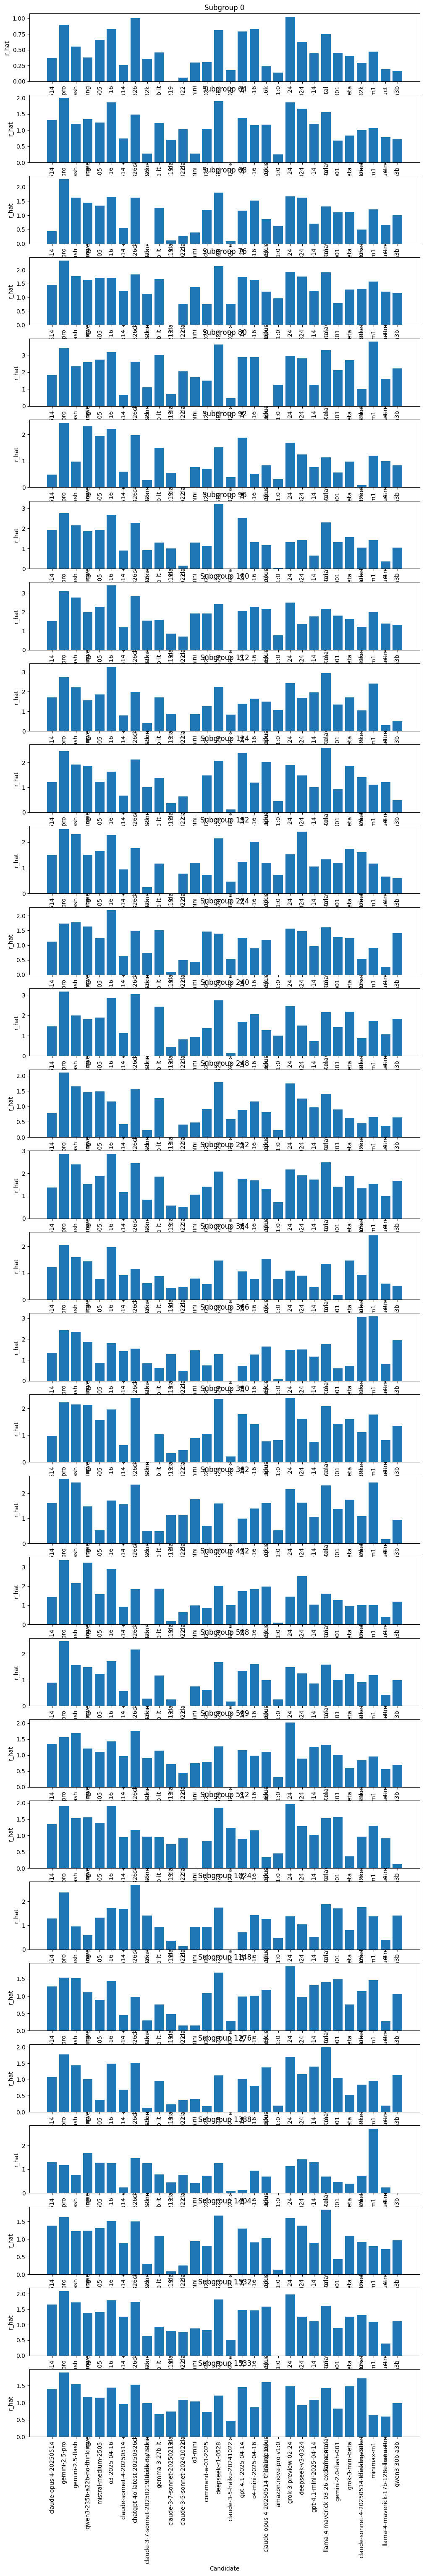

In [18]:
import matplotlib.pyplot as plt

num_subgroups, num_candidates = population.population_utilities.shape
print(num_subgroups)
fig, axes = plt.subplots(num_subgroups, 1, figsize=(12, max(3, 2.5 * num_subgroups)), squeeze=False)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]

for row_idx, ax in enumerate(axes[:, 0]):
    subgroup = population.idx_to_subgroup[row_idx]
    r_hat = population.population_utilities[row_idx]
    ax.bar(np.arange(num_candidates), r_hat)
    ax.set_title(f'Subgroup {subgroup}')
    ax.set_ylabel('r_hat')
    # ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


/tmp/ipykernel_4123172/493319653.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


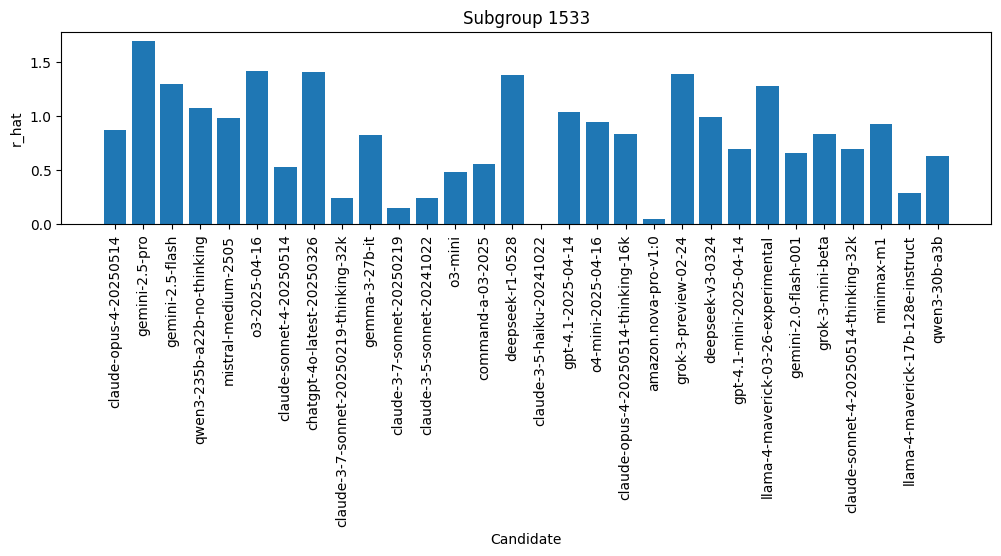

In [19]:
import matplotlib.pyplot as plt

# num_subgroups, num_candidates = population.population_utilities.shape
# print(num_subgroups)
fig, axes = plt.subplots(1, 1, figsize=(12, 2.5), squeeze=False)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]

for row_idx, ax in enumerate(axes[:, 0]):
    r_hat = population.single_latent_r_hat
    # r_hat = population.population_utilities[row_idx]
    ax.bar(np.arange(num_candidates), r_hat)
    ax.set_title(f'Subgroup {subgroup}')
    ax.set_ylabel('r_hat')
    # ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [20]:
from utils_3 import misspecification_error

In [21]:
population.subgroup_to_idx

{np.uint32(0): 0,
 np.uint32(64): 1,
 np.uint32(68): 2,
 np.uint32(76): 3,
 np.uint32(80): 4,
 np.uint32(92): 5,
 np.uint32(96): 6,
 np.uint32(100): 7,
 np.uint32(112): 8,
 np.uint32(124): 9,
 np.uint32(192): 10,
 np.uint32(224): 11,
 np.uint32(240): 12,
 np.uint32(248): 13,
 np.uint32(252): 14,
 np.uint32(364): 15,
 np.uint32(366): 16,
 np.uint32(380): 17,
 np.uint32(382): 18,
 np.uint32(432): 19,
 np.uint32(508): 20,
 np.uint32(509): 21,
 np.uint32(512): 22,
 np.uint32(1024): 23,
 np.uint32(1148): 24,
 np.uint32(1276): 25,
 np.uint32(1388): 26,
 np.uint32(1404): 27,
 np.uint32(1532): 28,
 np.uint32(1533): 29}

In [22]:
data = pw.data_by_subgroups([1533])
winners = data['winners']
losers = data['losers']

In [23]:
r_hat

array([0.8662449 , 1.69054534, 1.29205131, 1.07294522, 0.98078909,
       1.41185763, 0.53066785, 1.40682015, 0.24548598, 0.82114724,
       0.15274933, 0.24157195, 0.47744276, 0.55739174, 1.37892273,
       0.        , 1.03186101, 0.94712318, 0.83438548, 0.04681505,
       1.38594853, 0.98853284, 0.69555923, 1.27509429, 0.65927031,
       0.8318981 , 0.68954776, 0.9283025 , 0.28916375, 0.63114311])

In [24]:
r_hat = population.population_utilities[population.subgroup_to_idx[1533]]

misspecification_error(winners, losers, r_hat)

np.float64(222.6379514568623)

In [25]:
avg_utils = population.avg_utilities

In [26]:
misspecification_error(winners, losers, avg_utils)

np.float64(289.40231521518473)

In [27]:
msspec_r_hat_sum = 0
msspec_avg_sum = 0
baselines_sum = 0

subgroup_size = 0

subgroup_sizes = []
misspec_r_hats = []
misspec_r_singles = []

for i in range(len(population.subgroup_to_idx.keys())):
    subgroup = population.idx_to_subgroup[i]
    data = pw.data_by_subgroups([subgroup])
    winners = data['winners']
    losers = data['losers'] 
    # print(set(data['subgroups']))

    r_hat = population.population_utilities[i]
    # r_hat = population._scale_r_hat(r_hat)
    single_r_hat = population.single_latent_r_hat
    msspec_r_hat = misspecification_error(winners, losers, r_hat)
    msspec_avg = misspecification_error(winners, losers, single_r_hat)

    baseline = misspecification_error(winners, losers, np.zeros_like(single_r_hat))

    # if msspec_r_hat > msspec_avg:

    print('\nsubgroup:', subgroup)
    print('subgroup size:', len(winners))
    # print('r_hat:', r_hat)
    print('msspec r_hat:', msspec_r_hat)
    print('msspec single_latent:', msspec_avg)
    print('baseline:', baseline)

    print('normalized msspec r_hat:', msspec_r_hat / len(winners))
    print('normalized msspec single_latent:', msspec_avg / len(winners))
    print('normalized baseline:', baseline / len(winners))

    subgroup_sizes.append(len(winners))
    misspec_r_hats.append(msspec_r_hat)
    misspec_r_singles.append(msspec_avg)

    msspec_r_hat_sum += msspec_r_hat
    msspec_avg_sum += msspec_avg
    subgroup_size += len(winners)
    baselines_sum += baseline

print('\nmsspec_r_hat_sum', msspec_r_hat_sum)
print('msspec_avg_sum', msspec_avg_sum)
print('baseline sum', baselines_sum)
print('normalized_msspec_r_hat_sum', msspec_r_hat_sum / subgroup_size)
print('normalized_msspec_single_latent_sum', msspec_avg_sum / subgroup_size)
print('normalized baseline sum', baselines_sum / subgroup_size)

print('subgroup_size', subgroup_size)


subgroup: 0
subgroup size: 4091
msspec r_hat: 223.2768565854045
msspec single_latent: 282.18410809496703
baseline: 306.217473681906
normalized msspec r_hat: 0.05457757433033598
normalized msspec single_latent: 0.06897680471644269
normalized baseline: 0.07485149686675775

subgroup: 64
subgroup size: 1620
msspec r_hat: 258.35793002182305
msspec single_latent: 276.0973785044106
baseline: 347.19837854285333
normalized msspec r_hat: 0.15948020371717472
normalized msspec single_latent: 0.17043048055827814
normalized baseline: 0.21431998675484773

subgroup: 68
subgroup size: 1588
msspec r_hat: 239.95234668662653
msspec single_latent: 266.0087999851888
baseline: 362.24444068400675
normalized msspec r_hat: 0.1511034928757094
normalized msspec single_latent: 0.16751183878160503
normalized baseline: 0.22811362763476495

subgroup: 76
subgroup size: 1249
msspec r_hat: 249.38209575583164
msspec single_latent: 262.81300295106075
baseline: 318.63250481282444
normalized msspec r_hat: 0.199665408931810

In [28]:
idx = 2

for idx in list(population.idx_to_subgroup.keys()):
    subgroup = population.idx_to_subgroup[idx]
    data = pw.data_by_subgroups([subgroup])
    winners = data['winners']
    losers = data['losers']

    all_errs = []

    for i in range(len(population.subgroup_to_idx.keys())):
        r_hat = population.population_utilities[i]
        msspec_r_hat = misspecification_error(winners, losers, r_hat, beta=0.5)
        # print(msspec_r_hat)
        all_errs.append(msspec_r_hat)

    all_errs = np.asarray(all_errs)

    if idx != np.argmin(all_errs):
        print(np.min(all_errs))
        print(np.argmin(all_errs))

264.7462750415384
12
264.0412702209559
12


In [29]:
population.single_latent_r_hat.max()

np.float64(1.6905453411959082)

In [30]:
population.population_utilities.max()

np.float64(3.783071299132577)

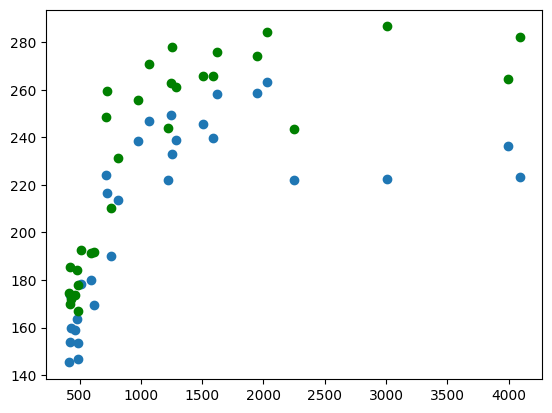

In [31]:
subgroup_sizes = np.asarray(subgroup_sizes)
misspec_r_hats = np.asarray(misspec_r_hats)
misspec_r_singles = np.asarray(misspec_r_singles)

plt.scatter(x=subgroup_sizes, y=misspec_r_hats)
plt.scatter(x=subgroup_sizes, y=misspec_r_singles, c='green')

In [32]:
misspecification_error(winners, losers, np.zeros_like(single_r_hat))

np.float64(340.6234437094288)

In [33]:
from utils_3 import borda_from_population_utilities

In [34]:
borda_scores, ranking = borda_from_population_utilities(population.population_utilities, population.voter_distr, beta=1.0)

In [35]:
true_ranking = np.argsort(-population.avg_utilities)

In [36]:
from utils_3 import leaderboard_dist

/tmp/ipykernel_4123172/2094080155.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


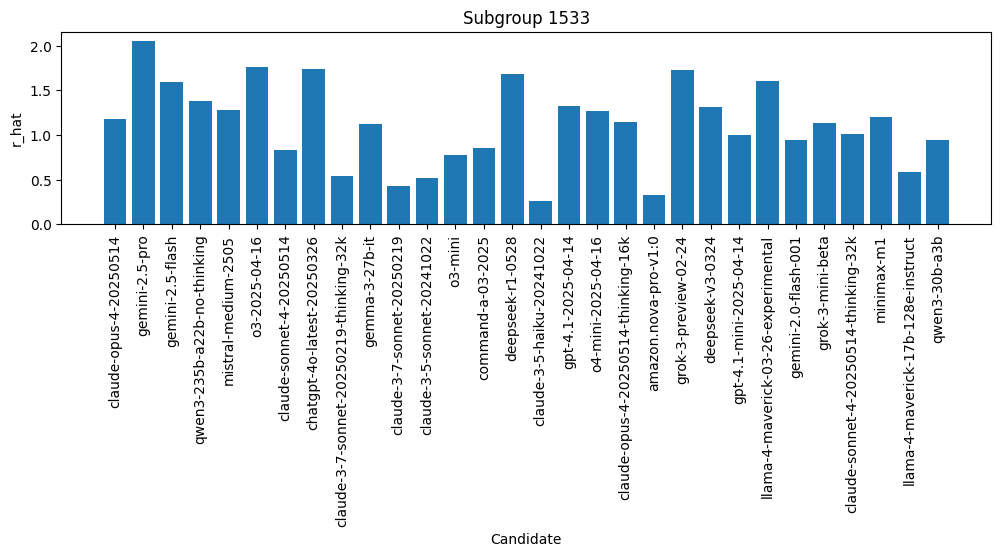

In [37]:
import matplotlib.pyplot as plt

# num_subgroups, num_candidates = population.population_utilities.shape
# print(num_subgroups)
fig, axes = plt.subplots(1, 1, figsize=(12, 2.5), squeeze=False)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]

for row_idx, ax in enumerate(axes[:, 0]):
    r_hat = population.avg_utilities
    # r_hat = population.population_utilities[row_idx]
    ax.bar(np.arange(num_candidates), r_hat)
    ax.set_title(f'Subgroup {subgroup}')
    ax.set_ylabel('r_hat')
    # ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [38]:
leaderboard_dist(ranking, true_ranking, population.avg_utilities)

(np.float64(1.0011062813881704), np.int64(12))

In [39]:
ranking

array([ 1,  5,  7, 20, 14, 23,  2,  3, 16, 21,  4, 17,  0, 27, 18, 25,  9,
       26, 22, 24, 29, 13,  6, 12, 28,  8, 11, 10, 19, 15])

In [40]:
true_ranking

array([ 1,  5,  7, 20, 14, 23,  2,  3, 16, 21,  4, 17, 27,  0, 18, 25,  9,
       26, 22, 24, 29, 13,  6, 12, 28,  8, 11, 10, 19, 15])

In [41]:
train_data = ds['train']

In [42]:
population.idx_to_subgroup[0]

np.uint32(0)

In [43]:
data_0 = pw.data_by_subgroups([0])
print(data_0['winners'])
print(data_0['losers'])

[ 4  1 15 ... 20  7 23]
[ 6  8 26 ...  4  1 14]


In [44]:
from scipy.special import expit


def borda_from_population_utilities(utilities, voter_dist=None, cand_dist=None, beta=1.0):
    utilities = np.asarray(utilities)
    V, C = utilities.shape

    if voter_dist is None:
        voter_dist = np.ones(V, dtype=float) / V
    else:
        voter_dist = np.asarray(voter_dist, dtype=float)
        assert voter_dist.shape == (V,)
        voter_dist = voter_dist / voter_dist.sum()

    if cand_dist is None:
        cand_dist = np.ones(C, dtype=float) / C
    else:
        cand_dist = np.asarray(cand_dist, dtype=float)
        assert cand_dist.shape == (C,)
        cand_dist = cand_dist / cand_dist.sum()

    P = np.zeros((C, C), dtype=float)

    for v, u in enumerate(utilities):
        diffs = u[:, None] - u[None, :]
        P += voter_dist[v] * expit(beta * diffs)

    np.fill_diagonal(P, 0.0) # remove this?
    borda_scores = P @ cand_dist
    ranking = np.argsort(-borda_scores)

    return borda_scores, ranking

In [45]:
borda_scores, single_ranking = borda_from_population_utilities(population.single_latent_r_hat[None], beta=0.5)
leaderboard_dist(single_ranking, true_ranking, population.avg_utilities)

(np.float64(1.0014534662037675), np.int64(5))

In [46]:
from scipy.special import rel_entr

p = population.single_latent_r_hat
q = population.avg_utilities
kl = np.sum(rel_entr(p, q))

print(kl)

-7.25592256039919


In [47]:
print(population.voter_distr)
print(population.subgroup_to_idx)

[0.10922732 0.04325306 0.04239868 0.03334757 0.01100016 0.01644684
 0.01244193 0.02029156 0.01140065 0.0137502  0.02167993 0.02616543
 0.03356117 0.04018262 0.03444225 0.01900999 0.01941048 0.02856838
 0.01305602 0.01302932 0.06010039 0.05425322 0.01134725 0.01281572
 0.01583275 0.03262669 0.01132055 0.05203717 0.10666417 0.08033855]
{np.uint32(0): 0, np.uint32(64): 1, np.uint32(68): 2, np.uint32(76): 3, np.uint32(80): 4, np.uint32(92): 5, np.uint32(96): 6, np.uint32(100): 7, np.uint32(112): 8, np.uint32(124): 9, np.uint32(192): 10, np.uint32(224): 11, np.uint32(240): 12, np.uint32(248): 13, np.uint32(252): 14, np.uint32(364): 15, np.uint32(366): 16, np.uint32(380): 17, np.uint32(382): 18, np.uint32(432): 19, np.uint32(508): 20, np.uint32(509): 21, np.uint32(512): 22, np.uint32(1024): 23, np.uint32(1148): 24, np.uint32(1276): 25, np.uint32(1388): 26, np.uint32(1404): 27, np.uint32(1532): 28, np.uint32(1533): 29}


In [48]:
!pip install choix
import choix

In [49]:
pw.M

30

In [50]:
wl_matrix = np.zeros((pw.M, pw.M))

In [51]:
for i in range(len(data_0['winners'])):
    wl_matrix[data_0['winners'][i], data_0['losers'][i]] += 1

print(wl_matrix)

[[ 0.  4. 16.  5.  8.  5.  5.  3.  5. 11.  9.  9.  8.  7.  6.  4.  8.  5.
   4. 10.  7. 11.  9.  7.  3.  7.  2.  5. 10.  8.]
 [14.  0.  7. 11. 11.  6.  9.  6. 11.  4. 10.  1. 11. 14.  6. 12.  8.  2.
  11.  8.  6.  4.  8.  5.  3.  6.  7.  6.  6.  9.]
 [10.  8.  0.  8.  4.  9.  7.  3.  8.  5. 10. 10.  4.  7.  3.  6.  6.  3.
   4.  9.  3.  6.  6.  6.  6.  3.  2.  6.  5.  3.]
 [ 7.  2.  7.  0.  8.  3.  5.  3.  3.  6.  4.  6.  6.  7.  5.  2.  5.  4.
   4.  7.  7.  4.  5.  6.  5.  4. 12.  2.  3.  4.]
 [15.  9. 12.  9.  0.  5. 14.  6.  9.  6.  6.  4.  9.  8.  8.  8.  7.  5.
   6.  9.  3.  4.  8.  2.  4.  8.  7.  6.  3.  4.]
 [ 8.  4.  8.  9.  7.  0.  8.  5.  9.  5.  7. 12.  4. 11.  5.  8.  4.  3.
   8.  5.  7.  4.  3.  2.  4.  6.  5.  7.  7.  6.]
 [ 7.  7.  5.  6.  5.  3.  0.  4. 10.  5.  5.  3.  3. 11.  6.  7.  6.  2.
   1.  6.  2.  2.  3.  5.  3.  5.  3.  1.  2.  8.]
 [12.  7.  8.  6. 10.  9.  3.  0.  6.  8. 14. 11.  9.  8.  3.  8.  6. 10.
   4.  3.  5.  5.  7.  1.  7.  3.  2.  3.  5.  6.]


In [52]:
choix_r_hat = choix.ilsr_pairwise_dense(wl_matrix, alpha=0.1)
print(population._scale_r_hat(choix_r_hat))
scaled_choix_r_hat = population._scale_r_hat(choix_r_hat)

[0.35386469 0.88457369 0.52560953 0.35762722 0.67964031 0.82571165
 0.27655404 1.00146347 0.38947734 0.45663894 0.         0.05917826
 0.3174866  0.31243651 0.80668962 0.17098937 0.74373507 0.82241978
 0.22976712 0.15008838 0.94768141 0.58243459 0.43366589 0.75284163
 0.46005395 0.39670416 0.33810063 0.46249723 0.20852751 0.18984766]


In [53]:
print(population._scale_r_hat(population.population_utilities[0]))
scaled_weighed_r_hat = population._scale_r_hat(population.population_utilities[0])

[0.37295042 0.89704903 0.54922143 0.37472821 0.65893046 0.83491868
 0.26011902 1.00488074 0.35843299 0.45801925 0.         0.05380283
 0.2976592  0.3013995  0.81284813 0.17666439 0.79506285 0.83200942
 0.23754746 0.13586947 1.02656993 0.62751375 0.44659612 0.75388846
 0.45314884 0.40739471 0.29170753 0.47409061 0.19077365 0.16202414]


In [54]:
def bt_neg_log_likelihood(r_free, winners, losers, n_items, cand_distr=None, beta=1.0):
    """
    r_free: parameters for items 0..n_items-2
    last item's reward is fixed to 0 for identifiability
    winners, losers: arrays of item indices for each comparison
    """
    
    r = np.concatenate([r_free, [0.0]])  # fix last reward = 0

    diff = beta * (r[winners] - r[losers])
    
    # log sigma(diff) = -log(1 + exp(-diff))
    # use stable form:
    # if cand_distr is not None:
    #     weighted_terms = np.logaddexp(0.0, -diff) / (cand_distr[winners] * cand_distr[losers])
    # else:
    weighted_terms = np.logaddexp(0.0, -diff)
    nll = np.sum(weighted_terms) # TODO: normalize by probability of sampling pair
    return nll

In [55]:
from scipy.optimize import minimize

x0 = np.zeros(pw.M - 1)

result = minimize(
    bt_neg_log_likelihood,
    x0,
    args=(data_0['winners'], data_0['losers'], pw.M - 1, None),
    method="L-BFGS-B"
)

if not result.success:
    raise RuntimeError(f"Bradley-Terry fit failed: {result.message}")

r_hat = np.concatenate([result.x, [0.0]])

print(population._scale_r_hat(r_hat))
scaled_unweighed_r_hat = population._scale_r_hat(r_hat)

[0.36927176 0.91832422 0.54483025 0.37131463 0.70495698 0.85915606
 0.28746914 1.04815906 0.40399692 0.47347988 0.         0.06101756
 0.32912721 0.32432854 0.84198382 0.17495582 0.7757349  0.85907462
 0.23545504 0.15343484 0.99383352 0.60454981 0.4495355  0.78703705
 0.47677828 0.40918552 0.34721393 0.47740275 0.21369836 0.19334607]


In [56]:
distr = np.zeros(pw.M)
for i in range(len(data_0['winners'])):
    distr[data_0['winners'][i]] += 1
    distr[data_0['losers'][i]] += 1

# print(distr)

In [57]:
def bt_neg_log_likelihood_weighted(r_free, winners, losers, n_items, cand_distr=None, beta=1.0):
    """
    r_free: parameters for items 0..n_items-2
    last item's reward is fixed to 0 for identifiability
    winners, losers: arrays of item indices for each comparison
    """
    
    r = np.concatenate([r_free, [0.0]])  # fix last reward = 0

    diff = beta * (r[winners] - r[losers])
    
    # log sigma(diff) = -log(1 + exp(-diff))
    # use stable form:
    # if cand_distr is not None:
    weighted_terms = np.logaddexp(0.0, -diff) / (cand_distr[winners] * cand_distr[losers])
    # else:
    # weighted_terms = np.logaddexp(0.0, -diff)
    nll = np.sum(weighted_terms) # TODO: normalize by probability of sampling pair
    return nll

In [58]:
from scipy.optimize import minimize

x0 = np.zeros(pw.M - 1)

result = minimize(
    bt_neg_log_likelihood_weighted,
    x0,
    args=(data_0['winners'], data_0['losers'], pw.M - 1, distr),
    method="L-BFGS-B"
)

if not result.success:
    raise RuntimeError(f"Bradley-Terry fit failed: {result.message}")

r_hat = np.concatenate([result.x, [0.0]])

print(population._scale_r_hat(r_hat))
scaled_weighed_r_hat = population._scale_r_hat(r_hat)

[0.3826322  0.90486577 0.56416034 0.37147553 0.67453625 0.83961077
 0.25880862 1.00924705 0.36493287 0.46900726 0.         0.04393408
 0.30765379 0.28969898 0.82838298 0.18504979 0.79426284 0.85128406
 0.25944467 0.13826964 1.02535872 0.63561764 0.45593675 0.75513355
 0.46192577 0.41042869 0.30030682 0.4778388  0.1921806  0.15809731]


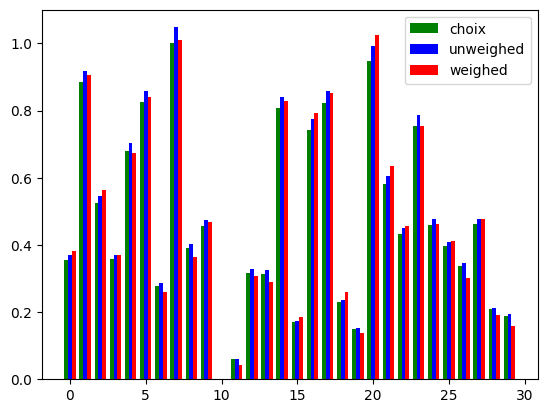

In [59]:
import matplotlib.pyplot as plt

x = np.arange(len(scaled_choix_r_hat))
width = 0.25

plt.bar(x - width, scaled_choix_r_hat, width=width, color='green', label='choix')
plt.bar(x, scaled_unweighed_r_hat, width=width, color='blue', label='unweighed')
plt.bar(x + width, scaled_weighed_r_hat, width=width, color='red', label='weighed')

plt.legend()
plt.show()

In [60]:
print(population.population_utilities.min(axis=0).shape)
population.population_utilities.max(axis=1)

(30,)


array([1.02656993, 1.99753534, 2.26681982, 2.34010414, 3.7830713 ,
       2.43435604, 3.20436776, 3.40502641, 3.26646476, 2.59372197,
       2.50555505, 2.18565623, 3.17016234, 2.09776786, 2.85938969,
       2.41724831, 3.09029929, 2.39430142, 2.57640404, 3.35125433,
       2.47894344, 2.02315449, 1.97553027, 2.67559093, 1.86543024,
       1.988791  , 2.71262873, 1.83366594, 2.08807521, 1.89159427])